## 9. Fill Probability Distribution Analysis vs. Absolute Price Difference to Midprice

**Dataset:** BTC-USDT, 2026-03-26  
**Input:** Parquet file from LOB research pipeline

---

### Sections
1. Data Loading & Feature Engineering
2. Probability Density (Empirical vs Gaussian)
3. Stylized Facts — Heavy Tails & Skewness
4. Q-Q Plot — Deviation from Normality
5. Dependence Structure — Scatter & Copula
6. Advanced Visualization — Mean-Covariance Ellipsoids & Projections

---
## 0. Imports & Configuration

I'll give you the processed data and you can run this ipynotebook, for the data process section, it is illustrate it in README.md

In [12]:
from __future__ import annotations

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import seaborn as sns

from scipy import stats
from scipy.stats import norm, kurtosis, skew, gaussian_kde
from scipy.special import ndtr                   # normal CDF

# Copula / dependence
from scipy.stats import spearmanr, kendalltau

# ── Style ─────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Paths ─────────────────────────────────────────────────────────────────
PARQUET_PATH = '../../../data/parquet/events/source=COINBASE/symbol=BTC-USDT/date=2026-03-23/part.parquet'  # ← update this
SYMBOL       = 'BTC-USDT'
DATE         = '2026-03-23'


# ── Reproducibility ───────────────────────────────────────────────────────
RNG = np.random.default_rng(42)

print('Imports OK')

Imports OK


---
## 1. Data Loading & Feature Engineering

In [13]:
# ── Load raw events ───────────────────────────────────────────────────────
events = pd.read_parquet(PARQUET_PATH)
print(f'Loaded {len(events):,} rows | columns: {events.columns.tolist()}')
events.head(3)

Loaded 12,107,549 rows | columns: ['order_id', 'session_id', 'symbol', 'source', 'side', 'event_type', 'event_seq', 'ts', 'price', 'size', 'remaining_size', 'reason']


,order_id,session_id,symbol,source,side,event_type,event_seq,ts,price,size,remaining_size,reason
0,24e226e6-8b7d-4f8e-b54c-9d8d4ccf284c,1,BTC-USDT,COINBASE,ASK,CANCEL,1,1774224000002619000,67994.22,0.147098,0.0,CANCELLED
1,2ace63e5-3c81-4382-bddd-0d32cb23bec6,1,BTC-USDT,COINBASE,BID,CANCEL,1,1774224000002619000,67791.14,0.073769,0.0,CANCELLED
2,5a68866d-bd72-4aef-9583-a5158cc647c4,1,BTC-USDT,COINBASE,ASK,CANCEL,1,1774224000002619000,68104.54,0.734297,0.0,CANCELLED


In [14]:
# ── Midprice reconstruction ───────────────────────────────────────────────
# For each timestamp we need best_bid and best_ask to compute midprice.
# Strategy: take the last ADD/MODIFY price per side at each event timestamp.

# ── Midprice reconstruction ───────────────────────────────────────────────
def compute_midprice(df: pd.DataFrame) -> pd.Series:
    """
    Rolling best-bid / best-ask from ADD events.
    Returns a Series aligned to df.index.
    """
    quotes = df[df['event_type'].isin(['ADD', 'MODIFY'])].copy()
    quotes = quotes.sort_values('ts')

    bid = quotes[quotes['side'] == 'BID'].groupby('ts')['price'].max()
    ask = quotes[quotes['side'] == 'ASK'].groupby('ts')['price'].min()

    # Expand to full timeline using forward-fill
    timeline = df['ts'].sort_values().unique()
    best_bid = bid.reindex(timeline).ffill()
    best_ask = ask.reindex(timeline).ffill()
    midprice = (best_bid + best_ask) / 2

    # Map back to original df rows
    return df['ts'].map(midprice)


events['midprice'] = compute_midprice(events)

# ── Absolute price distance to midprice at time of ADD ────────────────────
adds = events[events['event_type'] == 'ADD'].copy()
adds['abs_dist'] = (adds['price'] - adds['midprice']).abs()

# ── Fill label: did this order_id ever reach a FILL event? ────────────────
filled_ids = set(
    events.loc[events['event_type'] == 'FILL', 'order_id'].unique()
)
adds['filled'] = adds['order_id'].isin(filled_ids).astype(int)

# Drop rows with missing midprice (early rows before both sides quoted)
adds.dropna(subset=['midprice', 'abs_dist'], inplace=True)

print(f'ADD orders: {len(adds):,} | filled: {adds["filled"].sum():,} '
      f'({adds["filled"].mean()*100:.1f}%)')
adds[['order_id', 'side', 'price', 'midprice', 'abs_dist', 'filled']].head()

ADD orders: 6,051,656 | filled: 6,170 (0.1%)


,order_id,side,price,midprice,abs_dist,filled
21,26f0b533-7f5e-4b7b-874d-7aade1347121,ASK,67886.15,67878.060,8.090,0
24,1aaa1b48-2c48-4167-bcfc-d70d291f5233,BID,67793.09,67839.620,46.530,0
25,b3ff8f5c-a210-4840-8ccd-a2357d729efb,BID,67860.79,67873.470,12.680,0
28,7b3d21fd-d1bc-4b14-9f56-6aed27163bc9,BID,67647.40,67766.775,119.375,0
29,3647b4f5-0b74-4fba-847b-e4f5589f0aab,BID,67856.73,67871.440,14.710,0


In [15]:
# ── Fixed-width price interval binning ───────────────────────────────────
#
# Fill rate is defined at the INTERVAL level:
#
#   fill_rate(Δp) = #{orders with abs_dist ∈ [Δp, Δp+δ) that received a FILL}
#                  ─────────────────────────────────────────────────────────────
#                  #{all orders with abs_dist ∈ [Δp, Δp+δ)}
#
# We offer two granularities:
#   • USD bins  : fixed absolute dollar width (e.g. $1 per tick)
#   • bps bins  : relative width in basis points of midprice
#                 (better for comparing across price regimes)

# ── USD-denominated bins ──────────────────────────────────────────────────
BIN_WIDTH_USD = 1.0          # $1 per bin  ← tune to your tick size
MAX_DIST_USD  = adds['abs_dist'].quantile(0.995)   # clip extreme outliers

bin_edges_usd = np.arange(0, MAX_DIST_USD + BIN_WIDTH_USD, BIN_WIDTH_USD)
adds['dist_bin_usd'] = pd.cut(
    adds['abs_dist'],
    bins=bin_edges_usd,
    right=False,          # intervals are [left, right)
    include_lowest=True,
)

bin_stats_usd = (
    adds.groupby('dist_bin_usd', observed=True)
    .agg(
        fill_rate   = ('filled', 'mean'),   # filled orders / total orders in interval
        n_total     = ('filled', 'count'),  # total orders placed in interval
        n_filled    = ('filled', 'sum'),    # filled orders in interval
        dist_left   = ('abs_dist', 'min'),  # left edge of interval
        dist_mid    = ('abs_dist', 'median'),
    )
    .reset_index()
)
# Confidence interval for the fill rate using Wilson score
def wilson_ci(p: pd.Series, n: pd.Series, z: float = 1.96):
    """Wilson score confidence interval for a proportion."""
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half   = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (centre - half).clip(0), (centre + half).clip(0, 1)

bin_stats_usd['ci_lo'], bin_stats_usd['ci_hi'] = wilson_ci(
    bin_stats_usd['fill_rate'], bin_stats_usd['n_total']
)
# Drop bins with fewer than 10 orders (unreliable estimate)
bin_stats_usd = bin_stats_usd[bin_stats_usd['n_total'] >= 10].copy()

# ── bps-denominated bins ──────────────────────────────────────────────────
BIN_WIDTH_BPS = 5            # 5 bps per bin
adds['abs_dist_bps'] = (
    (adds['abs_dist'] / adds['midprice']) * 10_000
)
MAX_DIST_BPS  = adds['abs_dist_bps'].quantile(0.995)
bin_edges_bps = np.arange(0, MAX_DIST_BPS + BIN_WIDTH_BPS, BIN_WIDTH_BPS)

adds['dist_bin_bps'] = pd.cut(
    adds['abs_dist_bps'],
    bins=bin_edges_bps,
    right=False,
    include_lowest=True,
)
bin_stats_bps = (
    adds.groupby('dist_bin_bps', observed=True)
    .agg(
        fill_rate   = ('filled', 'mean'),
        n_total     = ('filled', 'count'),
        n_filled    = ('filled', 'sum'),
        dist_mid    = ('abs_dist_bps', 'median'),
    )
    .reset_index()
)
bin_stats_bps['ci_lo'], bin_stats_bps['ci_hi'] = wilson_ci(
    bin_stats_bps['fill_rate'], bin_stats_bps['n_total']
)
bin_stats_bps = bin_stats_bps[bin_stats_bps['n_total'] >= 10].copy()

# Alias used by downstream cells (USD version as default)
bin_stats = bin_stats_usd.rename(columns={'fill_rate': 'fill_prob'})

print(f'USD bins : {len(bin_stats_usd)} intervals  '
      f'(width={BIN_WIDTH_USD} USD)')
print(f'bps bins : {len(bin_stats_bps)} intervals  '
      f'(width={BIN_WIDTH_BPS} bps)')
print()
print(bin_stats_usd[['dist_bin_usd','n_total','n_filled','fill_rate',
                      'ci_lo','ci_hi']].head(10).to_string(index=False))

USD bins : 255 intervals  (width=1.0 USD)
bps bins : 8 intervals  (width=5 bps)

dist_bin_usd  n_total  n_filled  fill_rate    ci_lo    ci_hi
  [0.0, 1.0)    42525       209   0.004915 0.004293 0.005626
  [1.0, 2.0)    34617       110   0.003178 0.002637 0.003828
  [2.0, 3.0)    47912       106   0.002212 0.001830 0.002675
  [3.0, 4.0)    56949       117   0.002054 0.001715 0.002461
  [4.0, 5.0)    72743       147   0.002021 0.001720 0.002375
  [5.0, 6.0)    69589       112   0.001609 0.001338 0.001936
  [6.0, 7.0)    72268       124   0.001716 0.001439 0.002045
  [7.0, 8.0)    75488       126   0.001669 0.001402 0.001987
  [8.0, 9.0)    77676       114   0.001468 0.001222 0.001763
 [9.0, 10.0)    79782       126   0.001579 0.001327 0.001880


---
## 2. Probability Density — Empirical vs Gaussian

μ = 40.9625   σ = 103.6361


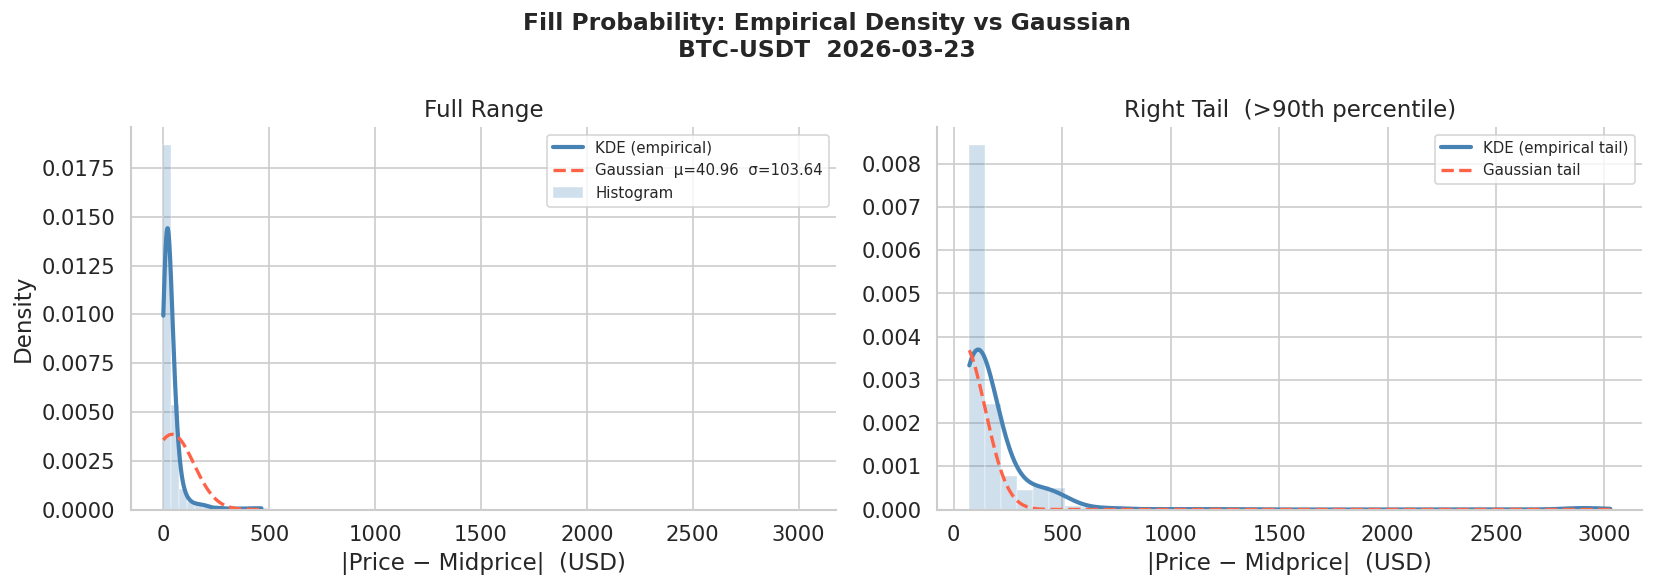

In [16]:
# We analyse the distribution of `abs_dist` for FILLED orders
x = adds.loc[adds['filled'] == 1, 'abs_dist'].values

mu, sigma = x.mean(), x.std(ddof=1)
print(f'μ = {mu:.4f}   σ = {sigma:.4f}')

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'Fill Probability: Empirical Density vs Gaussian\n'
    f'{SYMBOL}  {DATE}',
    fontsize=14, fontweight='bold'
)

# ── Left: full range ──────────────────────────────────────────────────────
ax = axes[0]
xgrid = np.linspace(x.min(), np.percentile(x, 99.5), 500)

# KDE
kde = gaussian_kde(x, bw_method='scott')
ax.plot(xgrid, kde(xgrid), lw=2.5, color='steelblue', label='KDE (empirical)')

# Matching Gaussian
ax.plot(xgrid, norm.pdf(xgrid, mu, sigma), lw=2, ls='--',
        color='tomato', label=f'Gaussian  μ={mu:.2f}  σ={sigma:.2f}')

ax.hist(x, bins=80, density=True, alpha=0.25, color='steelblue',
        label='Histogram')
ax.set_xlabel('|Price − Midprice|  (USD)')
ax.set_ylabel('Density')
ax.set_title('Full Range')
ax.legend(fontsize=9)

# ── Right: tail (>95th pct) ───────────────────────────────────────────────
ax = axes[1]
tail_thresh = np.percentile(x, 90)
xt = x[x > tail_thresh]
xgrid_t = np.linspace(tail_thresh, x.max(), 400)

kde_t = gaussian_kde(xt, bw_method='scott')
ax.plot(xgrid_t, kde_t(xgrid_t), lw=2.5, color='steelblue', label='KDE (empirical tail)')
ax.plot(xgrid_t, norm.pdf(xgrid_t, mu, sigma), lw=2, ls='--',
        color='tomato', label='Gaussian tail')
ax.hist(xt, bins=40, density=True, alpha=0.25, color='steelblue')
ax.set_xlabel('|Price − Midprice|  (USD)')
ax.set_title('Right Tail  (>90th percentile)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 3. Stylized Facts — Heavy Tails & Skewness

In [17]:
# ── Moment diagnostics ────────────────────────────────────────────────────
kurt_excess = kurtosis(x, fisher=True)   # excess kurtosis (Normal = 0)
skewness    = skew(x)

_, pval_sw = stats.shapiro(RNG.choice(x, min(len(x), 5000), replace=False))
_, pval_ks = stats.kstest(x, 'norm', args=(mu, sigma))

# Hill estimator for tail index α
def hill_estimator(data: np.ndarray, k: int = 100) -> float:
    """Hill (1975) estimator for the tail index using k upper order statistics."""
    sorted_desc = np.sort(data)[::-1]
    log_ratios  = np.log(sorted_desc[:k]) - np.log(sorted_desc[k])
    return 1.0 / log_ratios.mean()

k_hill   = max(50, int(0.05 * len(x)))
tail_idx = hill_estimator(x, k=k_hill)

print('=' * 55)
print(f'  Excess Kurtosis          : {kurt_excess:>10.4f}')
print(f'  (Normal = 0; >0 → heavy tails)')
print(f'  Skewness                 : {skewness:>10.4f}')
print(f'  Shapiro-Wilk  p-value    : {pval_sw:>10.4e}')
print(f'  KS vs Normal  p-value    : {pval_ks:>10.4e}')
print(f'  Hill tail index α (k={k_hill}): {tail_idx:>10.4f}')
print(f'  (α < 4 suggests infinite kurtosis; α < 2 infinite variance)')
print('=' * 55)

heavy = kurt_excess > 1.0
right_skew = skewness > 0.5

print(f'\n▸ Heavy tails detected    : {heavy}')
print(f'▸ Positive (right) skew   : {right_skew}')

  Excess Kurtosis          :   491.0968
  (Normal = 0; >0 → heavy tails)
  Skewness                 :    18.9174
  Shapiro-Wilk  p-value    : 1.2124e-89
  KS vs Normal  p-value    : 0.0000e+00
  Hill tail index α (k=308):     1.4464
  (α < 4 suggests infinite kurtosis; α < 2 infinite variance)

▸ Heavy tails detected    : True
▸ Positive (right) skew   : True


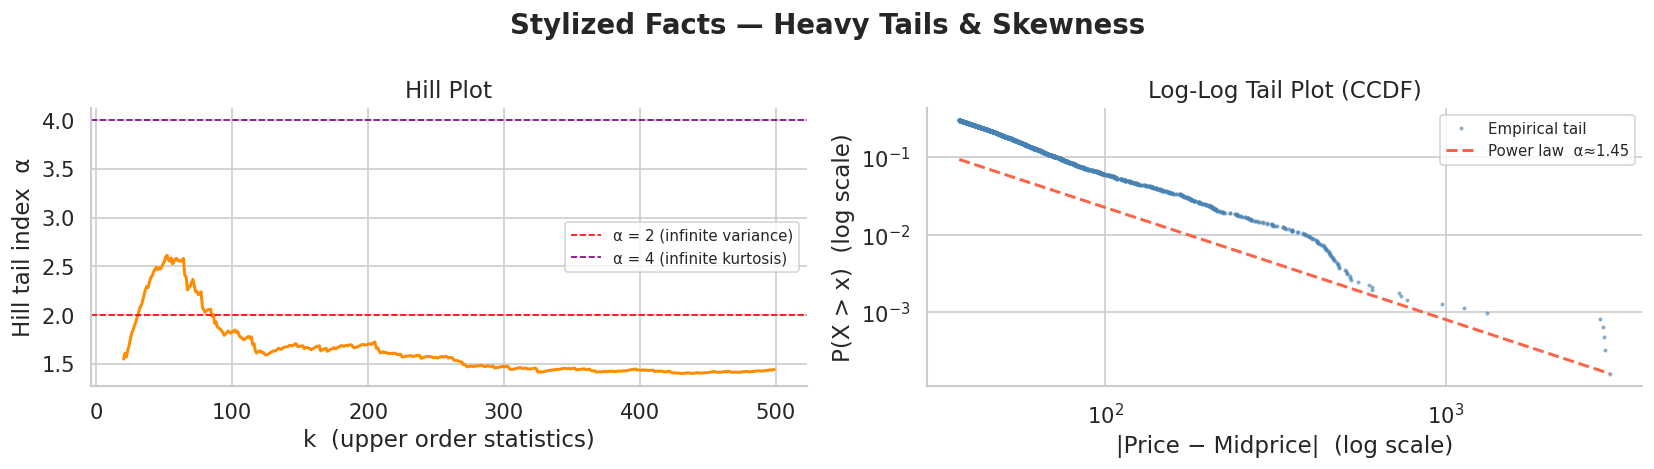

In [18]:
# ── Hill plot (tail index vs k) ───────────────────────────────────────────
ks     = np.arange(20, min(int(0.15 * len(x)), 500))
alphas = [hill_estimator(x, k) for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Stylized Facts — Heavy Tails & Skewness', fontweight='bold')

# Hill plot
ax = axes[0]
ax.plot(ks, alphas, color='darkorange', lw=1.8)
ax.axhline(2, ls='--', color='red',   lw=1, label='α = 2 (infinite variance)')
ax.axhline(4, ls='--', color='purple',lw=1, label='α = 4 (infinite kurtosis)')
ax.set_xlabel('k  (upper order statistics)')
ax.set_ylabel('Hill tail index  α')
ax.set_title('Hill Plot')
ax.legend(fontsize=9)

# Log-log tail
ax = axes[1]
sorted_x = np.sort(x)[::-1]
n        = len(sorted_x)
rank     = np.arange(1, n + 1) / n     # empirical CCDF
mask     = sorted_x > np.percentile(x, 70)
ax.loglog(sorted_x[mask], rank[mask], '.', ms=3, color='steelblue',
          alpha=0.5, label='Empirical tail')

# Pareto reference line
slope = -tail_idx
x_ref = np.linspace(np.log10(sorted_x[mask].min()),
                    np.log10(sorted_x[mask].max()), 100)
ax.loglog(10**x_ref,
          rank[mask][0] * (10**x_ref / sorted_x[mask][0])**slope,
          '--', color='tomato', lw=1.8,
          label=f'Power law  α≈{tail_idx:.2f}')
ax.set_xlabel('|Price − Midprice|  (log scale)')
ax.set_ylabel('P(X > x)  (log scale)')
ax.set_title('Log-Log Tail Plot (CCDF)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 4. Q-Q Plot — Deviation from Normality

Student-t fit: df=1.60  loc=22.2059  scale=14.8997


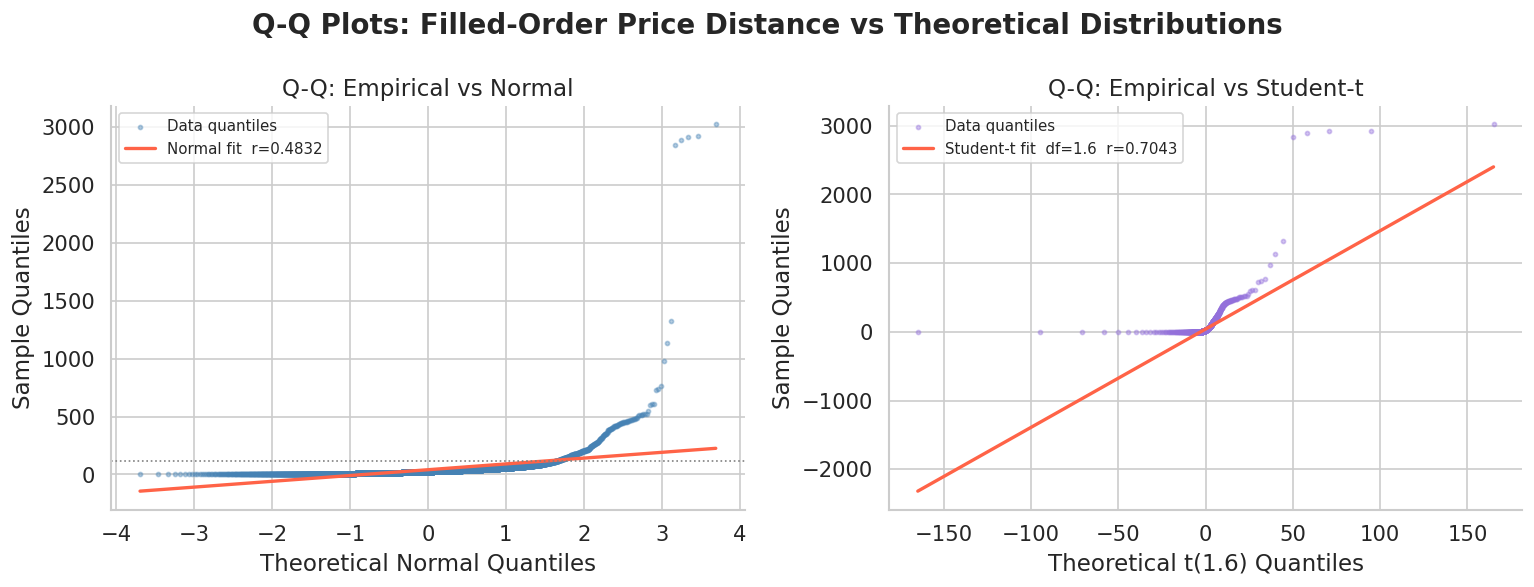

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Q-Q Plots: Filled-Order Price Distance vs Theoretical Distributions',
             fontweight='bold')

# ── Left: vs Normal ───────────────────────────────────────────────────────
ax = axes[0]
(osm, osr), (slope, intercept, r) = stats.probplot(x, dist='norm', fit=True)
ax.scatter(osm, osr, s=6, alpha=0.4, color='steelblue', label='Data quantiles')
ref_line = np.array([osm.min(), osm.max()])
ax.plot(ref_line, slope * ref_line + intercept,
        color='tomato', lw=2, label=f'Normal fit  r={r:.4f}')
ax.set_xlabel('Theoretical Normal Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.set_title('Q-Q: Empirical vs Normal')
ax.legend(fontsize=9)

# Annotate tail deviation
tail_q = np.percentile(osr, 95)
ax.axhline(tail_q, ls=':', color='grey', lw=1, label='95th pct')

# ── Right: vs Student-t (estimate df) ────────────────────────────────────
ax = axes[1]
df_t, loc_t, scale_t = stats.t.fit(x)
print(f'Student-t fit: df={df_t:.2f}  loc={loc_t:.4f}  scale={scale_t:.4f}')

(osm_t, osr_t), (slope_t, intercept_t, r_t) = stats.probplot(
    x, sparams=(df_t,), dist='t', fit=True
)
ax.scatter(osm_t, osr_t, s=6, alpha=0.4, color='mediumpurple',
           label='Data quantiles')
ref_t = np.array([osm_t.min(), osm_t.max()])
ax.plot(ref_t, slope_t * ref_t + intercept_t,
        color='tomato', lw=2, label=f'Student-t fit  df={df_t:.1f}  r={r_t:.4f}')
ax.set_xlabel(f'Theoretical t({df_t:.1f}) Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.set_title('Q-Q: Empirical vs Student-t')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 5. Dependence Structure — Scatter Plots & Copula

In [20]:
# ── Build a bivariate frame: abs_dist vs fill_probability (rolling) ───────
# We use a rolling window to get a smooth fill-probability estimate per order.

adds_sorted = adds.sort_values('ts').copy()
adds_sorted['fill_prob_roll'] = (
    adds_sorted['filled']
    .rolling(window=500, min_periods=50, center=True)
    .mean()
)
pair = adds_sorted[['abs_dist', 'fill_prob_roll']].dropna()

# Clip extreme abs_dist for clarity
clip_hi = pair['abs_dist'].quantile(0.995)
pair    = pair[pair['abs_dist'] <= clip_hi]

rho_s, pval_s = spearmanr(pair['abs_dist'], pair['fill_prob_roll'])
tau_k, pval_k = kendalltau(pair['abs_dist'], pair['fill_prob_roll'])

print(f"Spearman ρ = {rho_s:.4f}  (p={pval_s:.2e})")
print(f"Kendall  τ = {tau_k:.4f}  (p={pval_k:.2e})")

Spearman ρ = 0.0583  (p=0.00e+00)
Kendall  τ = 0.0461  (p=0.00e+00)


In [21]:
# ── Pseudo-observations (uniform marginals) for copula ────────────────────
def pseudo_obs(data: np.ndarray) -> np.ndarray:
    """Rank-based pseudo-observations mapped to (0,1)."""
    n    = len(data)
    rank = stats.rankdata(data)
    return rank / (n + 1)

u = pseudo_obs(pair['abs_dist'].values)
v = pseudo_obs(pair['fill_prob_roll'].values)

# ── Gaussian copula parameter ─────────────────────────────────────────────
# θ estimated via inversion of Spearman's ρ: ρ_S ≈ (6/π) arcsin(θ/2)
theta_gauss = 2 * np.sin(np.pi * rho_s / 6)
print(f'Gaussian copula  θ (linear corr) = {theta_gauss:.4f}')

# ── Gumbel copula parameter estimate from Kendall's τ ─────────────────────
# τ = 1 - 1/θ  →  θ = 1/(1-τ)
theta_gumbel = 1.0 / max(1e-6, 1.0 - tau_k)
print(f'Gumbel  copula  θ               = {theta_gumbel:.4f}')

Gaussian copula  θ (linear corr) = 0.0611
Gumbel  copula  θ               = 1.0483


The following do the LOWESS subsampling which is O(n^2) **PLEASE BE PATIENT** since my data poits are large

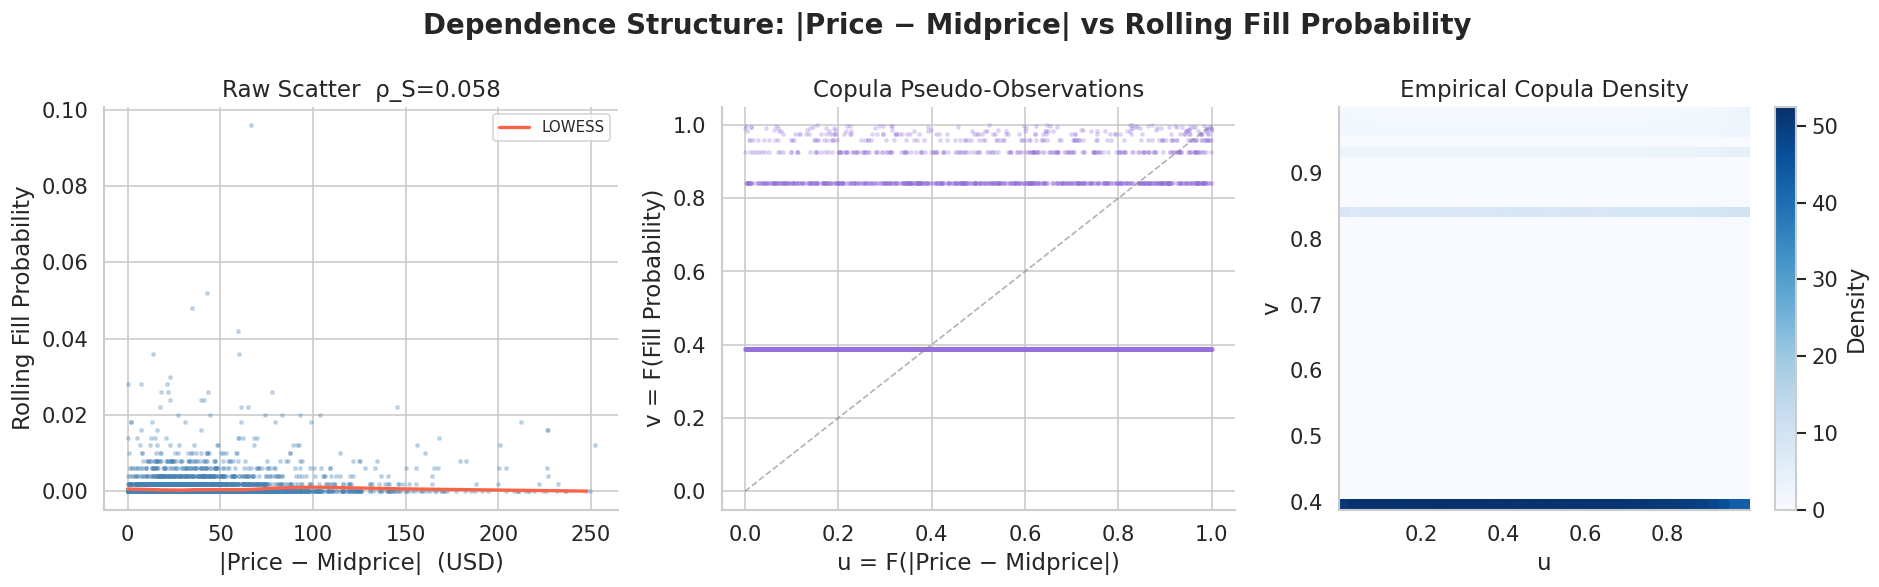


Interpretation:
  Spearman ρ=0.0583: Positive or near-zero dependence — unexpected, inspect data.


In [22]:
SCATTER_N = 5_000
LOWESS_N  = 2_000
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Dependence Structure: |Price − Midprice| vs Rolling Fill Probability',
             fontweight='bold')

# ── 1. Raw scatter ────────────────────────────────────────────────────────
ax = axes[0]
idx_s  = RNG.choice(len(pair), size=min(SCATTER_N, len(pair)), replace=False)
pair_s = pair.iloc[idx_s]
ax.scatter(pair_s['abs_dist'], pair_s['fill_prob_roll'], s=4, alpha=0.25, color='steelblue')
# Lowess smoother
from statsmodels.nonparametric.smoothers_lowess import lowess
idx_lowess = RNG.choice(len(pair), size=min(LOWESS_N, len(pair)), replace=False)
pair_l     = pair.iloc[idx_lowess]
lo = lowess(pair_l['fill_prob_roll'].values, pair_l['abs_dist'].values, frac=0.3, it=1, return_sorted=True)
ax.plot(lo[:, 0], lo[:, 1], color='tomato', lw=2, label='LOWESS')
ax.set_xlabel('|Price − Midprice|  (USD)')
ax.set_ylabel('Rolling Fill Probability')
ax.set_title(f'Raw Scatter  ρ_S={rho_s:.3f}')
ax.legend(fontsize=9)

# ── 2. Copula scatter (pseudo-observations) ───────────────────────────────
ax = axes[1]
ax.scatter(u[idx_s], v[idx_s], s=4, alpha=0.2, color='mediumpurple')
ax.set_xlabel('u = F(|Price − Midprice|)')
ax.set_ylabel('v = F(Fill Probability)')
ax.set_title('Copula Pseudo-Observations')

# Independence reference grid
ax.plot([0, 1], [0, 1], ls='--', color='grey', lw=1, alpha=0.6)

# ── 3. Copula density heatmap ─────────────────────────────────────────────
ax = axes[2]
h = ax.hist2d(u, v, bins=40, cmap='Blues', density=True)
plt.colorbar(h[3], ax=ax, label='Density')
ax.set_xlabel('u')
ax.set_ylabel('v')
ax.set_title('Empirical Copula Density')

plt.tight_layout()
plt.show()

print(f'\nInterpretation:')
print(f'  Spearman ρ={rho_s:.4f}: ', end='')
if rho_s < -0.3:
    print('Strong negative dependence — farther from midprice → lower fill prob.')
elif rho_s < 0:
    print('Weak negative dependence.')
else:
    print('Positive or near-zero dependence — unexpected, inspect data.')

---
## 6. Advanced Visualization — Mean-Covariance Ellipsoids & Linear Projections

In [23]:
class MeanCovariance:
    """
    Encapsulates the first two moments of a 2-D distribution and provides
    methods for ellipsoid plotting and linear projections.
    """

    def __init__(self, X: np.ndarray, robust: bool = False):
        """
        Parameters
        ----------
        X      : (n, 2) array
        robust : if True use median/IQR-based Minimum Covariance Determinant
                 approximation via scipy's robust scale estimate.
        """
        assert X.ndim == 2 and X.shape[1] == 2
        self.X = X

        if robust:
            from scipy.stats import trim_mean
            self.mean = np.array([
                trim_mean(X[:, 0], 0.05),
                trim_mean(X[:, 1], 0.05),
            ])
        else:
            self.mean = X.mean(axis=0)

        centred  = X - self.mean
        self.cov = centred.T @ centred / (len(X) - 1)

        vals, vecs = np.linalg.eigh(self.cov)
        order      = np.argsort(vals)[::-1]
        self.eigenvalues  = vals[order]
        self.eigenvectors = vecs[:, order]    # columns are principal directions

    # ── Ellipse patch ──────────────────────────────────────────────────────
    def confidence_ellipse_patch(
        self,
        n_std: float = 2.0,
        **kwargs,
    ) -> Ellipse:
        """
        Return a matplotlib Ellipse centred at `mean` covering ±n_std
        standard deviations along the principal axes.
        """
        w = 2 * n_std * np.sqrt(self.eigenvalues[0])
        h = 2 * n_std * np.sqrt(self.eigenvalues[1])
        # angle of principal eigenvector with x-axis
        angle = np.degrees(
            np.arctan2(self.eigenvectors[1, 0], self.eigenvectors[0, 0])
        )
        ellipse = Ellipse(
            xy=self.mean, width=w, height=h, angle=angle,
            **kwargs
        )
        return ellipse

    # ── Linear projection onto PC1 ─────────────────────────────────────────
    def project_pc1(self) -> np.ndarray:
        """Project data onto first principal component."""
        return (self.X - self.mean) @ self.eigenvectors[:, 0]

    # ── Summary ────────────────────────────────────────────────────────────
    def summary(self) -> None:
        print(f'  Mean       : {self.mean}')
        print(f'  Covariance :\n{self.cov}')
        print(f'  Eigenvalues: {self.eigenvalues}')
        pve = self.eigenvalues / self.eigenvalues.sum() * 100
        print(f'  PVE        : PC1={pve[0]:.1f}%  PC2={pve[1]:.1f}%')


# ── Build data matrix ─────────────────────────────────────────────────────
# Use log-transform of abs_dist for better scale behaviour
log_dist = np.log1p(pair['abs_dist'].values)
fill_p   = pair['fill_prob_roll'].values

X_raw   = np.column_stack([pair['abs_dist'].values, fill_p])
X_log   = np.column_stack([log_dist, fill_p])

mc      = MeanCovariance(X_log, robust=False)
mc_rob  = MeanCovariance(X_log, robust=True)

print('Standard Mean-Covariance:')
mc.summary()
print('\nRobust (trimmed) Mean-Covariance:')
mc_rob.summary()

Standard Mean-Covariance:
  Mean       : [3.4233306e+00 1.0078226e-03]
  Covariance :
[[6.61854807e-01 1.28619192e-04]
 [1.28619192e-04 1.11717184e-05]]
  Eigenvalues: [6.61854832e-01 1.11467232e-05]
  PVE        : PC1=100.0%  PC2=0.0%

Robust (trimmed) Mean-Covariance:
  Mean       : [3.45901522e+00 4.92189799e-04]
  Covariance :
[[6.63128200e-01 1.10219028e-04]
 [1.10219028e-04 1.14375956e-05]]
  Eigenvalues: [6.63128218e-01 1.14192757e-05]
  PVE        : PC1=100.0%  PC2=0.0%


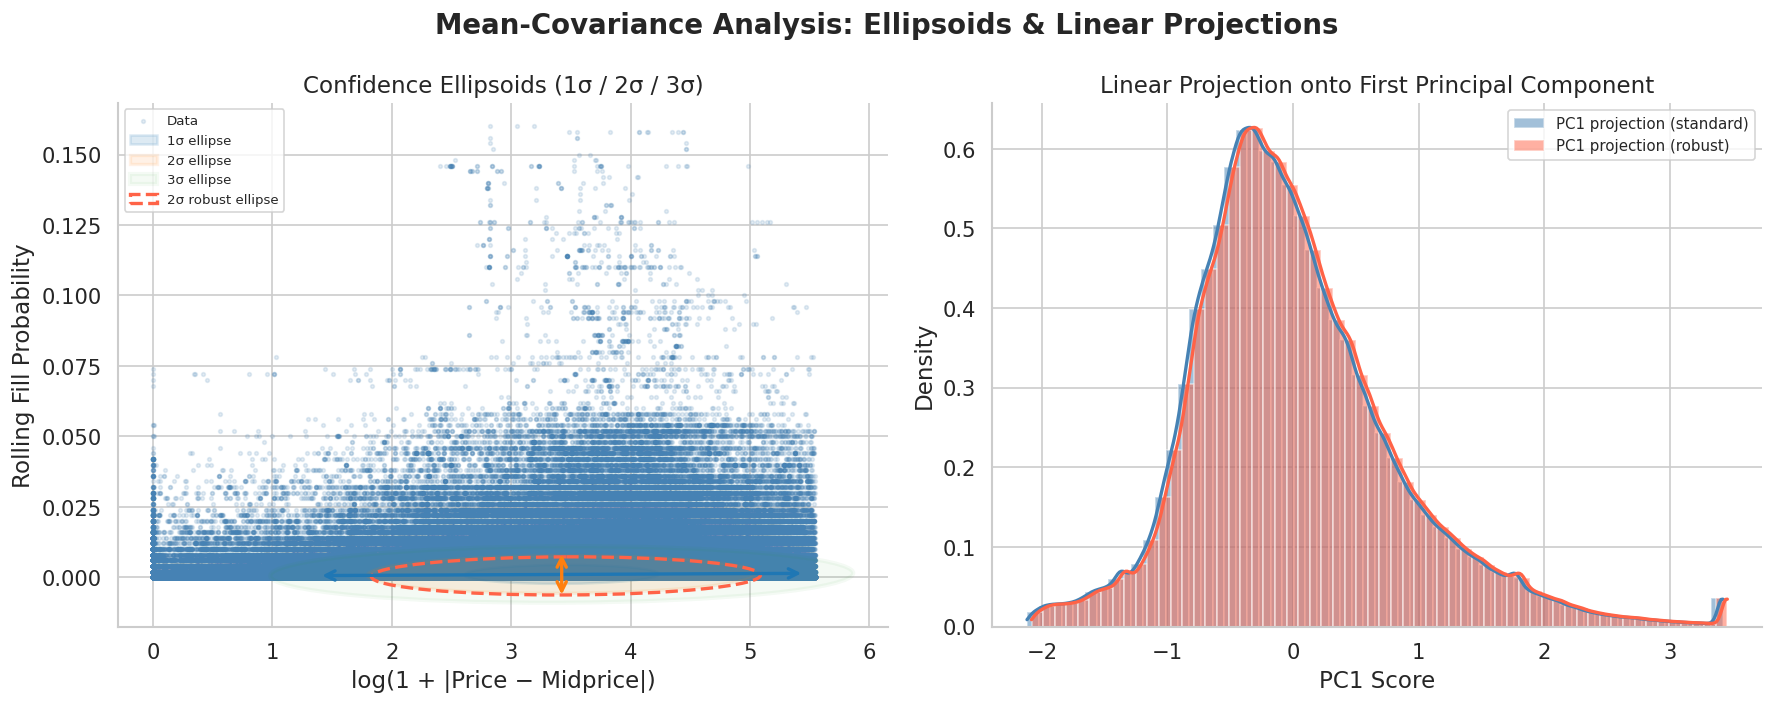


PC1 direction : [-9.99999981e-01 -1.94334700e-04]
Variance explained by PC1 : 100.0%


In [24]:
# ── Plot: Ellipsoids ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Mean-Covariance Analysis: Ellipsoids & Linear Projections',
             fontweight='bold')

# ── Left: Ellipsoids overlaid on scatter ──────────────────────────────────
ax = axes[0]
ax.scatter(X_log[:, 0], X_log[:, 1],
           s=5, alpha=0.15, color='steelblue', label='Data')

colors_std = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, (n_std, alpha, lw) in enumerate([(1, 0.15, 1.5), (2, 0.10, 2.0), (3, 0.05, 2.5)]):
    el = mc.confidence_ellipse_patch(
        n_std=n_std,
        edgecolor=colors_std[i], facecolor=colors_std[i],
        alpha=alpha, lw=lw,
        label=f'{n_std}σ ellipse'
    )
    ax.add_patch(el)

# Robust ellipse (dashed)
el_rob = mc_rob.confidence_ellipse_patch(
    n_std=2,
    edgecolor='tomato', facecolor='none', lw=2, ls='--',
    label='2σ robust ellipse'
)
ax.add_patch(el_rob)

# Plot principal axes
for i, (color, label) in enumerate(zip(['#1f77b4', '#ff7f0e'],
                                        ['PC1', 'PC2'])):
    vec   = mc.eigenvectors[:, i]
    scale = 2.5 * np.sqrt(mc.eigenvalues[i])
    ax.annotate('', xy=mc.mean + scale * vec,
                xytext=mc.mean - scale * vec,
                arrowprops=dict(arrowstyle='<->', color=color, lw=2))

ax.set_xlabel('log(1 + |Price − Midprice|)')
ax.set_ylabel('Rolling Fill Probability')
ax.set_title('Confidence Ellipsoids (1σ / 2σ / 3σ)')
ax.legend(fontsize=8)

# ── Right: PC1 projection histogram ───────────────────────────────────────
ax = axes[1]
proj_std = mc.project_pc1()
proj_rob = mc_rob.project_pc1()

ax.hist(proj_std, bins=60, density=True, alpha=0.5,
        color='steelblue', label='PC1 projection (standard)')
ax.hist(proj_rob, bins=60, density=True, alpha=0.5,
        color='tomato',    label='PC1 projection (robust)')

# Overlay KDEs
for arr, color in [(proj_std, 'steelblue'), (proj_rob, 'tomato')]:
    kde_p = gaussian_kde(arr, bw_method='scott')
    xg    = np.linspace(arr.min(), arr.max(), 400)
    ax.plot(xg, kde_p(xg), color=color, lw=2)

ax.set_xlabel('PC1 Score')
ax.set_ylabel('Density')
ax.set_title('Linear Projection onto First Principal Component')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

pve = mc.eigenvalues / mc.eigenvalues.sum() * 100
print(f'\nPC1 direction : {mc.eigenvectors[:, 0]}')
print(f'Variance explained by PC1 : {pve[0]:.1f}%')

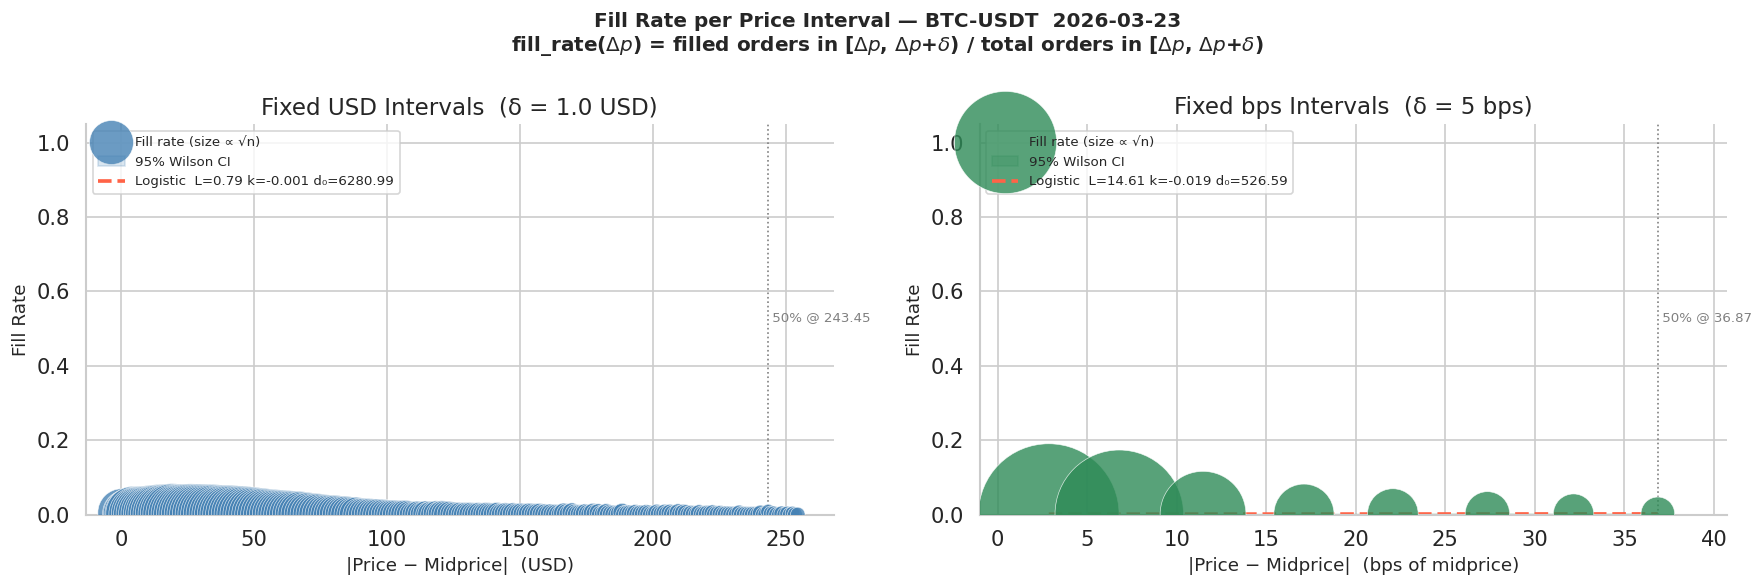

,dist_bin_usd,n_total,n_filled,fill_rate,ci_lo,ci_hi
0,"[0.0, 1.0)",42525,209,0.005,0.004,0.006
1,"[1.0, 2.0)",34617,110,0.003,0.003,0.004
2,"[2.0, 3.0)",47912,106,0.002,0.002,0.003
3,"[3.0, 4.0)",56949,117,0.002,0.002,0.002
4,"[4.0, 5.0)",72743,147,0.002,0.002,0.002
5,"[5.0, 6.0)",69589,112,0.002,0.001,0.002
6,"[6.0, 7.0)",72268,124,0.002,0.001,0.002
7,"[7.0, 8.0)",75488,126,0.002,0.001,0.002
8,"[8.0, 9.0)",77676,114,0.001,0.001,0.002
9,"[9.0, 10.0)",79782,126,0.002,0.001,0.002


In [27]:
# ── Fill rate curve: USD intervals ───────────────────────────────────────
from scipy.optimize import curve_fit

def logistic(d, L, k, d0):
    return L / (1 + np.exp(k * (d - d0)))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    f'Fill Rate per Price Interval — {SYMBOL}  {DATE}\n'
    r'fill_rate($\Delta p$) = filled orders in [$\Delta p$, $\Delta p$+$\delta$)'
    r' / total orders in [$\Delta p$, $\Delta p$+$\delta$)',
    fontsize=12, fontweight='bold'
)

for ax, bdf, xlabel, title, col in [
    (axes[0], bin_stats_usd, '|Price − Midprice|  (USD)',
     f'Fixed USD Intervals  (δ = {BIN_WIDTH_USD} USD)', 'steelblue'),
    (axes[1], bin_stats_bps, '|Price − Midprice|  (bps of midprice)',
     f'Fixed bps Intervals  (δ = {BIN_WIDTH_BPS} bps)', 'seagreen'),
]:
    x_mid = bdf['dist_mid'].values
    y_fr  = bdf['fill_rate'].values
    y_lo  = bdf['ci_lo'].values
    y_hi  = bdf['ci_hi'].values
    n     = bdf['n_total'].values

    # Bar chart sized by order count
    ax.bar(x_mid, y_fr, width=x_mid[1] - x_mid[0] if len(x_mid) > 1 else 1,
           alpha=0.25, color=col, align='center')

    # Fill rate points (size ∝ sample count)
    sc = ax.scatter(x_mid, y_fr,
                    s=np.sqrt(n) * 4, alpha=0.8,
                    color=col, edgecolors='white', lw=0.4,
                    zorder=3, label='Fill rate (size ∝ √n)')

    # 95% Wilson CI ribbon
    ax.fill_between(x_mid, y_lo, y_hi,
                    alpha=0.20, color=col, label='95% Wilson CI')

    # Logistic fit
    try:
        p0 = [1.0, 0.5, np.median(x_mid)]
        popt, _ = curve_fit(logistic, x_mid, y_fr, p0=p0, maxfev=10000)
        xfit = np.linspace(x_mid.min(), x_mid.max(), 400)
        ax.plot(xfit, logistic(xfit, *popt),
                color='tomato', lw=2.2, ls='--',
                label=f'Logistic  L={popt[0]:.2f} k={popt[1]:.3f} d₀={popt[2]:.2f}')
    except Exception as e:
        print(f'Logistic fit failed ({title}): {e}')

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Fill Rate', fontsize=11)
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)

    # Annotate the half-fill-rate point
    half_idx = np.argmin(np.abs(y_fr - 0.5))
    ax.axvline(x_mid[half_idx], color='grey', ls=':', lw=1)
    ax.text(x_mid[half_idx], 0.52,
            f' 50% @ {x_mid[half_idx]:.2f}',
            color='grey', fontsize=8)

plt.tight_layout()
plt.show()

# ── Side-by-side table: first 10 USD bins ─────────────────────────────────
display(
    bin_stats_usd[['dist_bin_usd', 'n_total', 'n_filled',
                   'fill_rate', 'ci_lo', 'ci_hi']]
    .head(15)
    .style
    .format({'fill_rate': '{:.3f}', 'ci_lo': '{:.3f}', 'ci_hi': '{:.3f}'})
    .set_caption('Fill Rate per USD Price Interval (first 15 bins)')
    .background_gradient(subset=['fill_rate'], cmap='RdYlGn')
)

---
## 7. Summary Table

In [26]:
summary = pd.DataFrame({
    'Metric': [
        'N (filled orders)',
        'Mean |dist|',
        'Std |dist|',
        'Skewness',
        'Excess Kurtosis',
        'Hill tail index α',
        'Shapiro-Wilk p-value',
        'KS vs Normal p-value',
        'Spearman ρ (dist vs fill_prob)',
        'Kendall τ  (dist vs fill_prob)',
        'Gaussian copula θ',
        'Gumbel  copula θ',
        'PVE PC1',
    ],
    'Value': [
        f'{len(x):,}',
        f'{mu:.4f}',
        f'{sigma:.4f}',
        f'{skewness:.4f}',
        f'{kurt_excess:.4f}',
        f'{tail_idx:.4f}',
        f'{pval_sw:.4e}',
        f'{pval_ks:.4e}',
        f'{rho_s:.4f}',
        f'{tau_k:.4f}',
        f'{theta_gauss:.4f}',
        f'{theta_gumbel:.4f}',
        f'{pve[0]:.1f}%',
    ],
})

display(summary.style.set_caption(
    f'Analysis Summary — {SYMBOL} {DATE}'
).set_table_styles([
    {'selector': 'th', 'props': [('font-weight', 'bold')]},
]))

,Metric,Value
0,N (filled orders),"6,170"
1,Mean |dist|,40.9625
2,Std |dist|,103.6361
3,Skewness,18.9174
4,Excess Kurtosis,491.0968
5,Hill tail index α,1.4464
6,Shapiro-Wilk p-value,1.2124e-89
7,KS vs Normal p-value,0.0000e+00
8,Spearman ρ (dist vs fill_prob),0.0583
9,Kendall τ (dist vs fill_prob),0.0461
